In [1]:
# %% 
# ============= BLOQUE 0 — Imports & Config (una sola fuente de verdad) =============
import os, re, glob, time, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --- Año coherente entre ALPHAEARTH y EUROCROP (EUCROPMAP solo 2018 o 2022) ---
YEAR = 2018

# --- Config dataset ---
ALPHA_DIR          = f"./data/ALPHAEARTH/{YEAR}"       # ALPHA_*.npy
EUROCROP_MASK_DIR  = f"./data/EUROCROP_MASK/{YEAR}"    # MASK_*.npy o MASK_*_128.npy
PATCH_SIZE         = 128
CHANNELS           = 64

# --- Clases EUROCROP (código, color_hex, nombre) ---
CLASSES = [
    (100, "#ff130f", "Artificial"),
    (211, "#a57000", "Trigo común"),
    (212, "#896054", "Trigo duro"),
    (213, "#e2007c", "Barley"),
    (214, "#aa007c", "Centeno"),
    (215, "#a05989", "Avena"),
    (216, "#ffd300", "Maíz"),
    (217, "#00a8e2", "Arroz"),
    (218, "#d69ebc", "Triticale"),
    (219, "#d69ebc", "Otros cereales"),
    (221, "#dda50a", "Papas"),
    (222, "#a800e2", "Remolacha azucarera"),
    (223, "#00af49", "Otras raíces"),
    (230, "#00af49", "Otros cultivos industriales no permanentes"),
    (231, "#ffff00", "Girasol"),
    (232, "#d1ff00", "Colza y colza nabo"),
    (233, "#267000", "Soya"),
    (240, "#f2a377", "Legumbres secas"),
    (250, "#e8bfff", "Cultivos forrajeros"),
    (290, "#696969", "Tierra arable sin cultivar"),
    (300, "#93cc93", "Bosques y arbustos (incl. cultivos permanentes)"),
    (500, "#e8ffbf", "Pastizales"),
    (600, "#a89e7f", "Suelo sin vegetación / líquenes"),
    (700, "#0793de", "Agua"),
    (800, "#7cafaf", "Humedales"),
]
CODES = [c for c, _, _ in CLASSES]
NAMES = [n for _, _, n in CLASSES]
code_to_idx = {c:i for i, c in enumerate(CODES)}

# --- Etiquetas ---
NUM_CLASSES      = len(CLASSES)  # 25
IGNORE_INDEX     = 255

# --- Entrenamiento ---
SEED             = 1337
BATCH_SIZE       = 16
EPOCHS           = 120
LR_MAX           = 1e-3          # max_lr para OneCycle (mejor con backbone pretrained)
WD               = 1e-4
MAX_GRAD_NORM    = 1.0
AMP_ENABLED      = True
USE_TTA_EVAL     = False         # activa si quieres TTA en val/test (un poco más lento)

# --- DataLoader (Windows/notebook safe) ---
NUM_WORKERS      = 0
PIN_MEMORY       = False

# --- Augmentations ---
AUG_FLIP_ROT     = True
AUG_CUTOUT       = True
AUG_INTENSITY    = True

# --- Visualización RGB sintético ---
BANDS_RGB        = (0, 31, 63)

# --- Filtro de cobertura válida de máscara ---
MIN_VALID_FRAC   = 0.08   # >=8% píxeles válidos

# --- Semillas & device ---
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device, "| YEAR:", YEAR)
print("Dirs:", ALPHA_DIR, "|", EUROCROP_MASK_DIR)


Device: cuda | YEAR: 2018
Dirs: ./data/ALPHAEARTH/2018 | ./data/EUROCROP_MASK/2018


In [2]:
# ============= BLOQUE 1 — Utilidades IO, normalización, remapeo, augs, RGB =========

def load_alpha(fp, channels=CHANNELS):
    """Carga ALPHA como [H,W,C]. Acepta [H,W,C] o [C,H,W]. Reemplaza rellenos -9999 por NaN."""
    X = np.load(fp)
    if X.ndim != 3:
        raise ValueError(f'Alpha dims inválidas: {X.shape}')
    if X.shape[0] == channels and X.shape[-1] != channels:
        X = np.moveaxis(X, 0, -1)             # [H,W,C]
    if X.shape[-1] != channels:
        raise ValueError(f'Alpha canales ≠ {channels}: {X.shape}')
    X = X.astype(np.float32)
    if np.any(X == -9999.0):
        X[X == -9999.0] = np.nan
    return X

def load_mask_any(fp):
    """Devuelve máscara 2D con CÓDIGOS EUROCROP (p.ej., 216, 700) o -1 (nodata)."""
    M = np.load(fp)
    if M.ndim == 2: return M
    if M.ndim == 3 and M.shape[0] == 1: return M[0]
    if M.ndim == 3 and M.shape[-1] == 1: return M[..., 0]
    raise ValueError(f"Máscara con dims inesperadas: {M.shape}")

def remap_eurocrop_codes_to_indices(M):
    """Códigos → índices [0..NUM_CLASSES-1], nodata/NaN → IGNORE_INDEX."""
    out = np.full(M.shape, IGNORE_INDEX, dtype=np.int64)
    if np.issubdtype(M.dtype, np.floating):
        mask_valid = ~np.isnan(M); Mv = M.copy(); Mv[~mask_valid] = -999999
    else:
        Mv = M
    for code, idx in code_to_idx.items():
        out[Mv == code] = idx
    return out

def center_crop_or_pad(img, th, tw, fill):
    H, W = img.shape[:2]
    y0 = max((H - th)//2, 0); x0 = max((W - tw)//2, 0)
    y1 = y0 + min(th, H);     x1 = x0 + min(tw, W)
    cropped = img[y0:y1, x0:x1, ...]
    ph = th - cropped.shape[0]; pw = tw - cropped.shape[1]
    if ph > 0 or pw > 0:
        out = np.full([th, tw] + ([] if img.ndim == 2 else [img.shape[2]]), fill, dtype=img.dtype)
        oy = (th - cropped.shape[0])//2; ox = (tw - cropped.shape[1])//2
        out[oy:oy+cropped.shape[0], ox:ox+cropped.shape[1], ...] = cropped
        return out
    return cropped

# Stats globales (se calculan en BLOQUE 4). Si son None, cae a normalizado por parche.
NORM_LO, NORM_HI = None, None

def robust_minmax_per_channel(X, lo=None, hi=None, p_lo=2, p_hi=98):
    if lo is not None and hi is not None:
        Y = np.empty_like(X, dtype=np.float32)
        for c in range(X.shape[-1]):
            den = max(float(hi[c] - lo[c]), 1e-6)
            base = np.nan_to_num(X[..., c], nan=lo[c])
            Y[..., c] = np.clip((base - lo[c]) / den, 0, 1)
        return Y
    # fallback por parche (solo antes de computar stats globales)
    Y = np.zeros_like(X, dtype=np.float32)
    for c in range(X.shape[-1]):
        v = X[..., c]; vv = v[~np.isnan(v)]
        if vv.size == 0: continue
        lo2, hi2 = np.percentile(vv, [p_lo, p_hi])
        den = max(hi2 - lo2, 1e-6)
        Y[..., c] = np.clip((np.nan_to_num(v, nan=lo2) - lo2) / den, 0, 1)
    return Y

def apply_sync_fliprot(X, Y):
    if AUG_FLIP_ROT:
        if np.random.rand() < 0.5:
            X = np.flip(X, 1).copy(); Y = np.flip(Y, 1).copy()
        if np.random.rand() < 0.5:
            X = np.flip(X, 0).copy(); Y = np.flip(Y, 0).copy()
        k = np.random.randint(0, 4)
        if k:
            X = np.rot90(X, k, (0,1)).copy(); Y = np.rot90(Y, k, (0,1)).copy()
    return X, Y

def aug_cutout(X, Y, p=0.35, max_boxes=2, box_frac=0.25):
    if AUG_CUTOUT and np.random.rand() < p:
        H, W = Y.shape
        for _ in range(np.random.randint(1, max_boxes+1)):
            bh = int(H * box_frac * (0.5 + np.random.rand()))
            bw = int(W * box_frac * (0.5 + np.random.rand()))
            y0 = np.random.randint(0, max(1, H - bh + 1))
            x0 = np.random.randint(0, max(1, W - bw + 1))
            X[y0:y0+bh, x0:x0+bw, :] = 0.0
    return X, Y

def aug_intensity(X, p_gain=0.5, p_noise=0.5, p_drop=0.25, max_drop=6):
    if not AUG_INTENSITY: return X
    if np.random.rand() < p_gain:
        gain = 0.9 + 0.2*np.random.rand(); bias = (np.random.rand()-0.5)*0.05
        X = np.clip(X*gain + bias, 0.0, 1.0)
    if np.random.rand() < p_noise:
        sigma = 0.01 + 0.02*np.random.rand()
        X = np.clip(X + np.random.normal(0, sigma, size=X.shape).astype(np.float32), 0.0, 1.0)
    if np.random.rand() < p_drop:
        C = X.shape[-1]; k = np.random.randint(1, max_drop+1)
        idx = np.random.choice(C, size=k, replace=False); X[..., idx] = 0.0
    return X

def to_rgb(X, picks=BANDS_RGB):
    rgb = np.zeros((X.shape[0], X.shape[1], 3), dtype=np.float32)
    for i, b in enumerate(picks):
        rgb[..., i] = np.clip(X[..., b], 0, 1)
    return rgb


In [3]:
# %%
# ============= BLOQUE 2 — Descubrir/validar pares (una vez) ========================

def find_pairs(alpha_dir=ALPHA_DIR, mask_dir=EUROCROP_MASK_DIR):
    """Devuelve lista de (alpha_path, mask_path, pid)."""
    pairs = []
    for ap in sorted(glob.glob(os.path.join(alpha_dir, 'ALPHA_*.npy'))):
        m = re.search(r'ALPHA_(\d+)\.npy$', os.path.basename(ap))
        if not m: continue
        pid = m.group(1)
        mp1 = os.path.join(mask_dir, f'MASK_{pid}_128.npy')
        mp2 = os.path.join(mask_dir, f'MASK_{pid}.npy')
        mp  = mp1 if os.path.isfile(mp1) else (mp2 if os.path.isfile(mp2) else None)
        if mp is None: continue
        pairs.append((ap, mp, pid))
    return pairs

def load_shapes_ok(ap, mp):
    X = load_alpha(ap); M = load_mask_any(mp)
    return (X.ndim == 3 and X.shape[-1] == CHANNELS and M.ndim == 2)

def valid_fraction(mp):
    M = load_mask_any(mp).astype(np.float32)
    V = (~np.isnan(M)) & (M != -1)
    return float(V.mean())

pairs_raw = [(ap, mp, pid) for (ap, mp, pid) in find_pairs() if load_shapes_ok(ap, mp)]
pairs_all = [(ap, mp, pid) for (ap, mp, pid) in pairs_raw if valid_fraction(mp) >= MIN_VALID_FRAC]

random.Random(SEED).shuffle(pairs_all)
n = len(pairs_all)
n_train = int(0.7*n); n_val = int(0.15*n)
pairs_train = pairs_all[:n_train]
pairs_val   = pairs_all[n_train:n_train+n_val]
pairs_test  = pairs_all[n_train+n_val:]

print(f"Pares válidos: total={n} | train={len(pairs_train)} | val={len(pairs_val)} | test={len(pairs_test)}")
if pairs_train:
    vf = [valid_fraction(mp) for _, mp, _ in pairs_train[:min(200, len(pairs_train))]]
    print("Cobertura válida (train) p50/p10/p90:",
          np.median(vf), np.percentile(vf,10), np.percentile(vf,90))



Pares válidos: total=2431 | train=1701 | val=364 | test=366
Cobertura válida (train) p50/p10/p90: 0.9639892578125 0.845819091796875 0.995550537109375


In [4]:

# ============= BLOQUE 3 — Dataset & DataLoaders (sin duplicar funciones) ===========

class PastisAEDataset(Dataset):
    def __init__(self, pairs, patch=PATCH_SIZE, train=True):
        self.pairs = list(pairs)
        self.patch = patch
        self.train = train

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        ap, mp, pid = self.pairs[idx]
        X = load_alpha(ap)                                # [H,W,64]
        M = load_mask_any(mp).astype(np.float32)          # [H,W] códigos EUROCROP

        X = center_crop_or_pad(X, self.patch, self.patch, fill=np.nan).astype(np.float32)
        M = center_crop_or_pad(M, self.patch, self.patch, fill=-1).astype(np.float32)

        Y = remap_eurocrop_codes_to_indices(M)           # índices 0..K-1 | 255 ignore

        if self.train:
            X, Y = apply_sync_fliprot(X, Y)

        # Normaliza con stats globales si ya están disponibles (BLOQUE 4 las define)
        X = robust_minmax_per_channel(X, lo=NORM_LO, hi=NORM_HI)

        if self.train:
            X, Y = aug_cutout(X, Y); X = aug_intensity(X)

        X = torch.from_numpy(np.transpose(np.ascontiguousarray(X, np.float32), (2,0,1)))
        Y = torch.from_numpy(np.ascontiguousarray(Y, np.int64))
        return X, Y, pid

ds_train = PastisAEDataset(pairs_train, train=True)
ds_val   = PastisAEDataset(pairs_val,   train=False)
ds_test  = PastisAEDataset(pairs_test,  train=False)

# Inicialmente con shuffle; en BLOQUE 4 rehacemos dlt con sampler balanceado
dlt = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False)
dlv = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False,
                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
dls = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False,
                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Batches -> train={len(dlt)} | val={len(dlv)} | test={len(dls)}")



Batches -> train=107 | val=23 | test=23


In [5]:

# ============= BLOQUE 4 — Pesos de clase, Norm-Stats y Sampler =====================

def compute_class_weights_from_pairs(pairs, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    # Conteo estable
    counts = np.zeros(num_classes, dtype=np.int64)
    for _, mp, _ in pairs:
        m = load_mask_any(mp)
        y = remap_eurocrop_codes_to_indices(center_crop_or_pad(m, PATCH_SIZE, PATCH_SIZE, fill=-1).astype(np.float32))
        v = y[y != ignore_index]
        if v.size: counts += np.bincount(v, minlength=num_classes)

    # Effective Number of Samples (Cui et al., 2019) + clipping
    beta = 0.999
    eff_num = (1.0 - np.power(beta, counts + 1e-8)) / (1.0 - beta)
    w = 1.0 / np.clip(eff_num, 1e-6, None)
    w = w / (w.mean() + 1e-12)
    w = np.clip(w, 0.2, 5.0).astype(np.float32)
    return w, counts

class_weights_np, class_counts = compute_class_weights_from_pairs(pairs_train)
print("Counts por clase:", class_counts.tolist())
print("Pesos (min/mean/max):", float(class_weights_np.min()), float(class_weights_np.mean()), float(class_weights_np.max()))

# --- Stats globales de normalización por canal (2–98%) ---
def compute_norm_stats(pairs, q_lo=2, q_hi=98, max_files=512):
    lo = np.full(CHANNELS, np.inf,  dtype=np.float32)
    hi = np.full(CHANNELS, -np.inf, dtype=np.float32)
    for ap, _, _ in pairs[:min(max_files, len(pairs))]:
        X = load_alpha(ap)
        for c in range(CHANNELS):
            v = X[..., c]; vv = v[~np.isnan(v)]
            if vv.size:
                p2, p98 = np.percentile(vv, [q_lo, q_hi])
                lo[c] = min(lo[c], p2); hi[c] = max(hi[c], p98)
    lo[~np.isfinite(lo)] = 0.0; hi[~np.isfinite(hi)] = 1.0
    return lo, hi

NORM_LO, NORM_HI = compute_norm_stats(pairs_train)
print("Norm stats ejemplo (c0): lo=", float(NORM_LO[0]), "hi=", float(NORM_HI[0]))

# --- Sampler balanceado por rareza de clases ---
def compute_sample_weights(pairs, class_weights):
    sw = []
    for _, mp, _ in pairs:
        M = remap_eurocrop_codes_to_indices(center_crop_or_pad(load_mask_any(mp), PATCH_SIZE, PATCH_SIZE, fill=-1).astype(np.float32))
        u = np.unique(M[M != IGNORE_INDEX])
        if u.size == 0: sw.append(0.0); continue
        sw.append(float(np.max(class_weights[u])))
    return np.array(sw, dtype=np.float32)

from torch.utils.data import WeightedRandomSampler
train_weights = compute_sample_weights(pairs_train, class_weights_np)
sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)

# Rehacer DataLoader de train usando sampler
dlt = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler,
                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False)
print(f"Batches(train) con sampler -> {len(dlt)}")



Counts por clase: [7585, 2782730, 143395, 847001, 3933, 1207, 3546332, 90, 1358, 31, 36492, 198712, 784, 83012, 221819, 630335, 5807, 213123, 156008, 236456, 9946355, 6883546, 9044, 0, 0]
Pesos (min/mean/max): 0.20000000298023224 0.5839999914169312 5.0
Norm stats ejemplo (c0): lo= -0.3278123736381531 hi= 0.18608227372169495
Batches(train) con sampler -> 107


In [6]:
# ============= BLOQUE 5 — Pérdidas y Métricas (definidas una vez) =================
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

# Menos smoothing (con pesos robustos no hace falta mucho); aumenta Dice un poco
ce_loss = nn.CrossEntropyLoss(weight=class_weights_t, ignore_index=IGNORE_INDEX, label_smoothing=0.0)

def soft_dice_loss(logits, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX, eps=1e-6):
    valid = (target != ignore_index)
    if valid.sum() == 0:
        return logits.new_tensor(0.0)
    probs = F.softmax(logits, dim=1).permute(0,2,3,1)[valid]  # [N,C]
    onehot = F.one_hot(target[valid], num_classes=num_classes).float()
    inter  = (probs * onehot).sum(dim=0)
    denom  = probs.sum(dim=0) + onehot.sum(dim=0)
    dice   = (2*inter + eps) / (denom + eps)
    return 1.0 - dice.mean()

W_DICE = 0.6
def total_loss(logits, target):
    lce   = torch.nan_to_num(ce_loss(logits, target),   nan=0.0, posinf=1e4, neginf=0.0)
    ldice = torch.nan_to_num(soft_dice_loss(logits, target), nan=0.0, posinf=1e4, neginf=0.0)
    return lce + W_DICE*ldice

@torch.no_grad()
def compute_confmat(pred, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    valid = (target != ignore_index)
    pred  = pred[valid]; target = target[valid]
    if target.numel() == 0:
        return torch.zeros((num_classes, num_classes), dtype=torch.int64, device=pred.device)
    k = (target * num_classes + pred).to(torch.int64)
    return torch.bincount(k, minlength=num_classes**2).reshape(num_classes, num_classes)

def iou_from_confmat(cm):
    tp = cm.diag().float()
    fp = cm.sum(0).float() - tp
    fn = cm.sum(1).float() - tp
    denom = tp + fp + fn
    iou = torch.where(denom > 0, tp / torch.clamp(denom, min=1e-6), torch.nan)
    return iou, torch.nanmean(iou)

def pixel_accuracy(cm):
    return (cm.diag().sum().float() / torch.clamp(cm.sum().float(), min=1e-6)).item()


In [7]:
# %%
# ============= BLOQUE 6 — Modelos (input adapter + backbone preentrenado) =========
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights
from torchvision.models import ResNet50_Weights
import torch.nn as nn
import torch.nn.functional as F

MODEL_NAME = 'deeplabv3_64'  # 'unet' o 'deeplabv3_64'

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        else:
            self.up = nn.ConvTranspose2d(in_ch//2, in_ch//2, 2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        dy = x2.size(2) - x1.size(2)
        dx = x2.size(3) - x1.size(3)
        if dy or dx:
            x1 = F.pad(x1, [dx//2, dx-dx//2, dy//2, dy-dy//2])
        return self.conv(torch.cat([x2, x1], dim=1))

class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 1)
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=CHANNELS, n_classes=NUM_CLASSES, bilinear=True):
        super().__init__()
        f = 64
        self.inc   = DoubleConv(n_channels, f)
        self.down1 = Down(f,   f*2)
        self.down2 = Down(f*2, f*4)
        self.down3 = Down(f*4, f*8)
        self.down4 = Down(f*8, f*8)
        self.up1   = Up(f*16, f*4, bilinear)
        self.up2   = Up(f*8,  f*2, bilinear)
        self.up3   = Up(f*4,  f,   bilinear)
        self.up4   = Up(f*2,  f,   bilinear)
        self.outc  = OutConv(f, n_classes)
    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2); x4 = self.down3(x3); x5 = self.down4(x4)
        x  = self.up1(x5, x4); x = self.up2(x, x3); x = self.up3(x, x2); x = self.up4(x, x1)
        return self.outc(x)

class InputAdapter(nn.Module):
    """64→3 canales para aprovechar backbone preentrenado (ImageNet)."""
    def __init__(self, in_ch=64, mid=16, out_ch=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, out_ch, 1, bias=False)
        )
    def forward(self, x): return self.net(x)

class DeeplabWithAdapter(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.adapter = InputAdapter(CHANNELS, 16, 3)

        # ✅ Opción 1 (recomendada): backbone preentrenado, head nueva con tus num_classes
        #    Evita el conflicto de "expected 21 but got 25"
        try:
            backbone_w = ResNet50_Weights.IMAGENET1K_V2
            self.net = deeplabv3_resnet50(
                weights=None,                      # sin pesos de VOC en la cabeza
                weights_backbone=backbone_w,       # backbone ResNet50 preentrenado
                aux_loss=True,
                num_classes=num_classes
            )
        except Exception:
            # Fallback para versiones viejas de torchvision sin weights_backbone
            self.net = deeplabv3_resnet50(
                weights=None, aux_loss=True, num_classes=num_classes
            )

        # --- Si prefieres Opción 2 (head VOC preentrenada y luego sustituir las últimas convs):
        # self.net = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT, aux_loss=True)
        # # Reemplazar las conv finales por convs de num_classes (manteniendo capas ASPP preentrenadas)
        # self.net.classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1)
        # if self.net.aux_classifier is not None:
        #     self.net.aux_classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.adapter(x)
        return self.net(x)   # dict: {'out', 'aux'}

def build_model():
    if MODEL_NAME == 'unet':
        net = UNet(n_channels=CHANNELS, n_classes=NUM_CLASSES).to(device)
        return net, (lambda out: out)
    elif MODEL_NAME == 'deeplabv3_64':
        net = DeeplabWithAdapter(NUM_CLASSES).to(device)
        return net, (lambda out: out['out'])
    else:
        raise ValueError("MODEL_NAME debe ser 'unet' o 'deeplabv3_64'")

model, get_logits = build_model()




In [8]:
# ============= BLOQUE 7 — Entrenamiento & Validación (más estable) =================
from torch.cuda.amp import autocast, GradScaler

def separate_wd_params(model, wd=WD):
    decay, no_decay = [], []
    for n,p in model.named_parameters():
        if not p.requires_grad: continue
        if p.dim() == 1 or 'bias' in n or 'bn' in n or 'norm' in n:
            no_decay.append(p)
        else:
            decay.append(p)
    return [{'params': decay, 'weight_decay': wd},
            {'params': no_decay, 'weight_decay': 0.0}]

optimizer = torch.optim.AdamW(separate_wd_params(model, WD), lr=LR_MAX)
scaler    = GradScaler(enabled=(device.type=='cuda') and AMP_ENABLED)

steps_per_epoch = max(1, len(dlt))
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR_MAX, epochs=EPOCHS, steps_per_epoch=steps_per_epoch
)

# (opcional) calentar 3–5 épocas congelando backbone
WARMUP_EPOCHS = 0
if hasattr(model, 'net') and hasattr(model.net, 'backbone') and WARMUP_EPOCHS > 0:
    for p in model.net.backbone.parameters(): p.requires_grad = False

def _forward_and_loss(X, Y):
    out = model(X)
    logits = out['out'] if isinstance(out, dict) else get_logits(out)
    loss = total_loss(logits, Y)
    # aux loss (solo CE para ahorrar)
    if isinstance(out, dict) and ('aux' in out) and (out['aux'] is not None):
        loss = loss + 0.4 * ce_loss(out['aux'], Y)
    return loss, logits

def train_one_epoch(epoch):
    model.train()
    # descongela backbone tras warmup
    if hasattr(model, 'net') and hasattr(model.net, 'backbone') and epoch == (WARMUP_EPOCHS+1):
        for p in model.net.backbone.parameters(): p.requires_grad = True

    t0, loss_acc, n = time.time(), 0.0, 0
    for X,Y,_ in dlt:
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)
        X = torch.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0).clamp_(0.0, 1.0)
        if (Y != IGNORE_INDEX).sum() == 0: continue

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(device.type=='cuda') and AMP_ENABLED):
            loss, logits = _forward_and_loss(X, Y)
        if not torch.isfinite(loss): continue

        scaler.scale(loss).backward()
        if MAX_GRAD_NORM:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        loss_acc += float(loss.detach().cpu()); n += 1
    return loss_acc / max(1,n), time.time()-t0

@torch.no_grad()
def predict_tta(X):
    outs = []
    def fwd(Z):
        o = model(Z); return o['out'] if isinstance(o, dict) else get_logits(o)
    outs.append(fwd(X))
    outs.append(torch.flip(fwd(torch.flip(X, [2])), [2]))  # flip vertical
    outs.append(torch.flip(fwd(torch.flip(X, [3])), [3]))  # flip horizontal
    Xr = X.transpose(2,3); outs.append(fwd(Xr).transpose(2,3))  # rot 90
    return torch.stack(outs, 0).mean(0)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_acc, n = 0.0, 0
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)
    for X,Y,_ in loader:
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)
        X = torch.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0).clamp_(0.0, 1.0)
        if (Y != IGNORE_INDEX).sum() == 0: continue

        with autocast(enabled=(device.type=='cuda') and AMP_ENABLED):
            loss, logits = _forward_and_loss(X, Y)
        if torch.isfinite(loss): loss_acc += float(loss.detach().cpu()); n += 1

        logits_eval = predict_tta(X) if USE_TTA_EVAL else logits
        preds = logits_eval.argmax(1)
        cm_total += compute_confmat(preds, Y)

    iou, miou = iou_from_confmat(cm_total)
    acc = pixel_accuracy(cm_total)
    return (loss_acc/max(1,n)), float(miou.item()), float(acc)

# Smoke test
with torch.no_grad():
    xb,yb,_ = next(iter(dlv))
    xb = xb.to(device); yb = yb.to(device)
    loss_smoke, _ = _forward_and_loss(xb, yb)
    print("✅ Smoke test | val loss:", float(loss_smoke.detach().cpu()))

# Loop
stamp = time.strftime("%Y%m%d_%H%M%S")
os.makedirs("./checkpoints", exist_ok=True)
ckpt_best = f'./checkpoints/{MODEL_NAME}_best_{stamp}.pt'
best = -1.0

print(f"Entrenando ({MODEL_NAME}) por {EPOCHS} épocas…")
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_time = train_one_epoch(epoch)
    va_loss, va_miou, va_acc = evaluate(dlv)
    print(f"[{epoch:03d}/{EPOCHS}] train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | mIoU={va_miou:.3f} | pixAcc={va_acc:.3f} | time={tr_time:.1f}s")
    if va_miou > best:
        best = va_miou
        torch.save({'model': model.state_dict(), 'epoch': epoch, 'best_miou': best}, ckpt_best)
        print(f"  ↳ 🥇 Nuevo best mIoU={best:.3f} @ {ckpt_best}")


C:\Users\LuisA\AppData\Local\Temp\ipykernel_11624\1618851189.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(device.type=='cuda') and AMP_ENABLED)


✅ Smoke test | val loss: 5.294293403625488
Entrenando (deeplabv3_64) por 120 épocas…


C:\Users\LuisA\AppData\Local\Temp\ipykernel_11624\1618851189.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=='cuda') and AMP_ENABLED):
C:\Users\LuisA\AppData\Local\Temp\ipykernel_11624\1618851189.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=='cuda') and AMP_ENABLED):


[001/120] train_loss=4.1252 | val_loss=3.2351 | mIoU=0.072 | pixAcc=0.585 | time=83.6s
  ↳ 🥇 Nuevo best mIoU=0.072 @ ./checkpoints/deeplabv3_64_best_20251028_160611.pt
[002/120] train_loss=3.0440 | val_loss=2.5621 | mIoU=0.083 | pixAcc=0.633 | time=82.2s
  ↳ 🥇 Nuevo best mIoU=0.083 @ ./checkpoints/deeplabv3_64_best_20251028_160611.pt
[003/120] train_loss=2.5218 | val_loss=2.1472 | mIoU=0.103 | pixAcc=0.668 | time=80.9s
  ↳ 🥇 Nuevo best mIoU=0.103 @ ./checkpoints/deeplabv3_64_best_20251028_160611.pt
[004/120] train_loss=2.2183 | val_loss=1.9139 | mIoU=0.121 | pixAcc=0.694 | time=81.2s
  ↳ 🥇 Nuevo best mIoU=0.121 @ ./checkpoints/deeplabv3_64_best_20251028_160611.pt
[005/120] train_loss=1.9983 | val_loss=1.7445 | mIoU=0.143 | pixAcc=0.716 | time=81.1s
  ↳ 🥇 Nuevo best mIoU=0.143 @ ./checkpoints/deeplabv3_64_best_20251028_160611.pt
[006/120] train_loss=1.8692 | val_loss=1.6581 | mIoU=0.155 | pixAcc=0.728 | time=81.1s
  ↳ 🥇 Nuevo best mIoU=0.155 @ ./checkpoints/deeplabv3_64_best_20251028_16

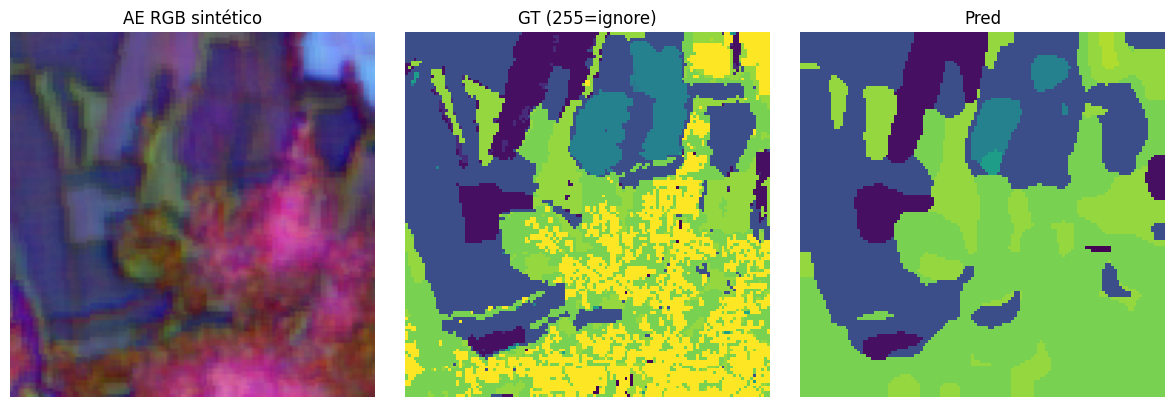

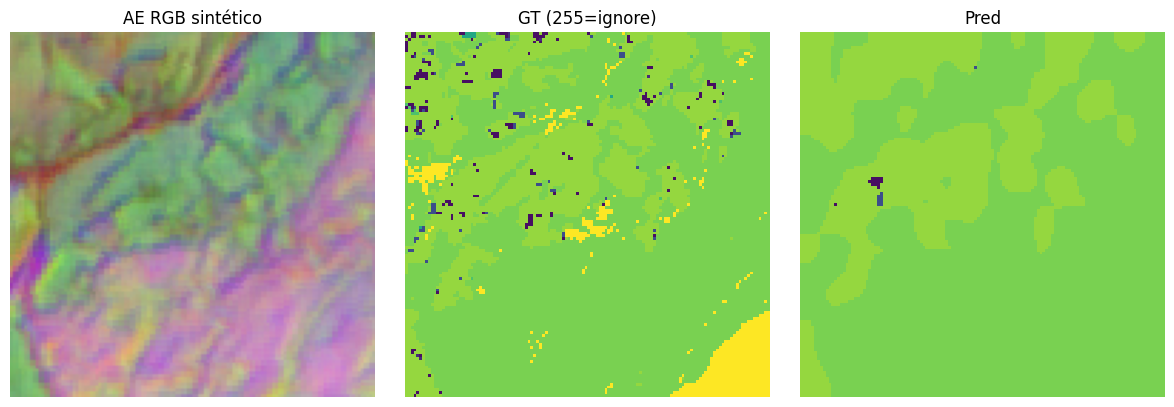

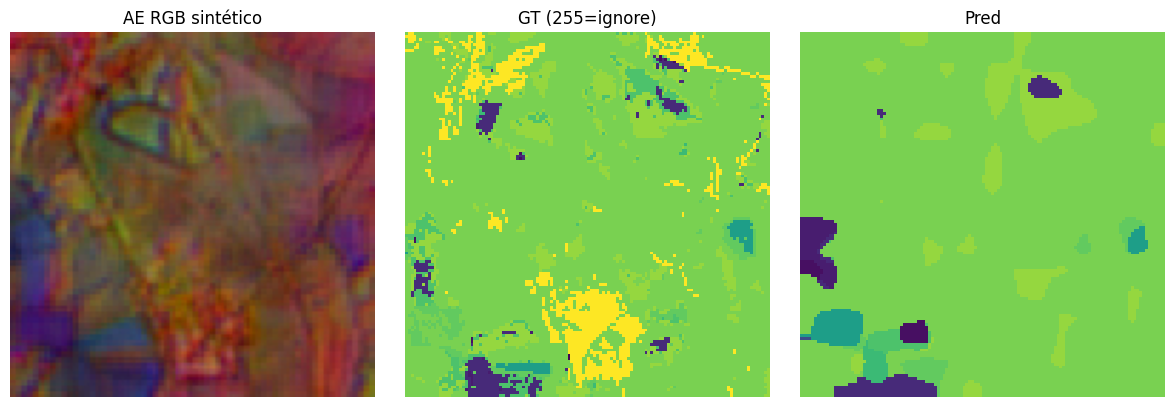

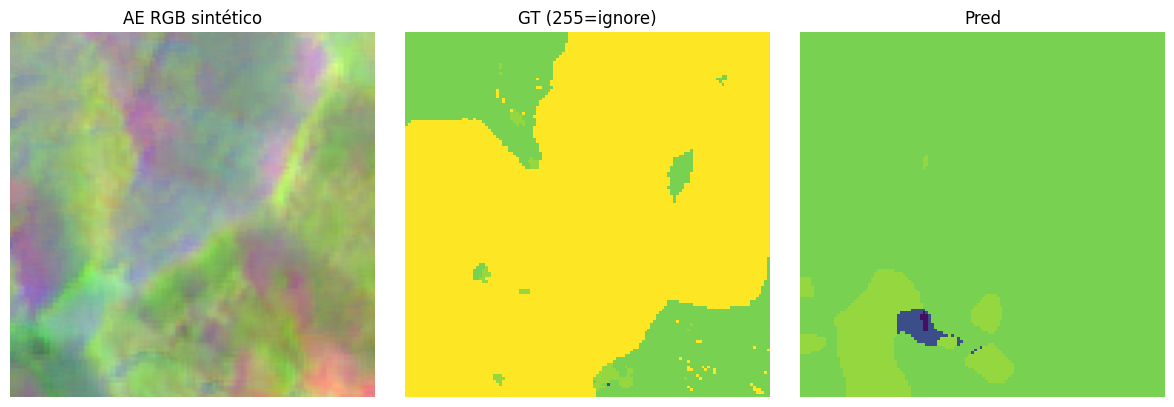

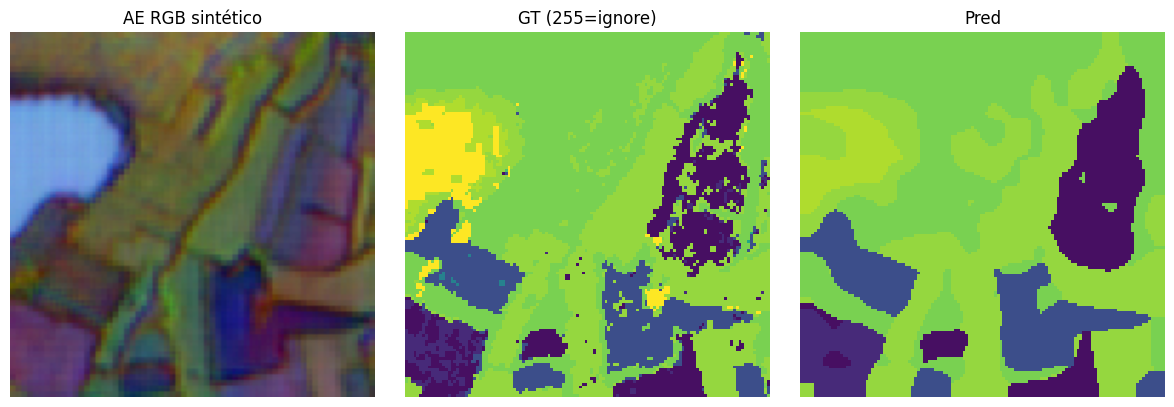

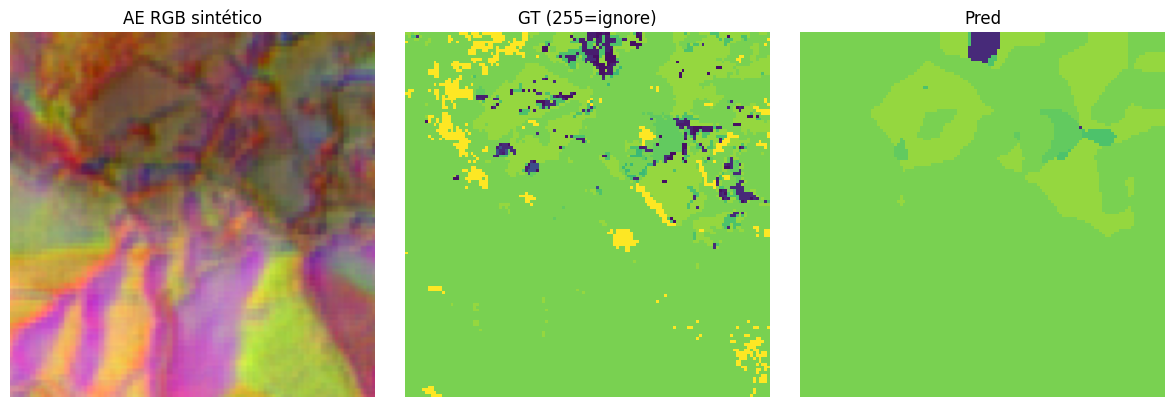

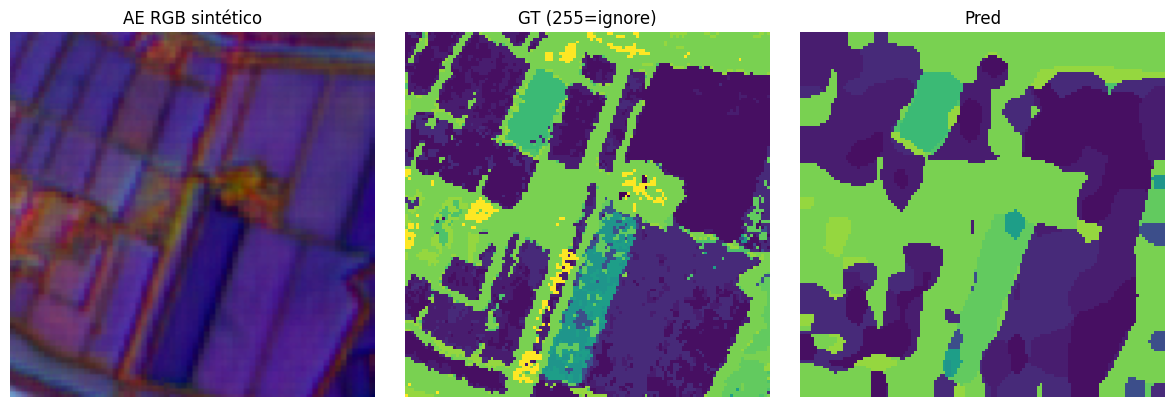

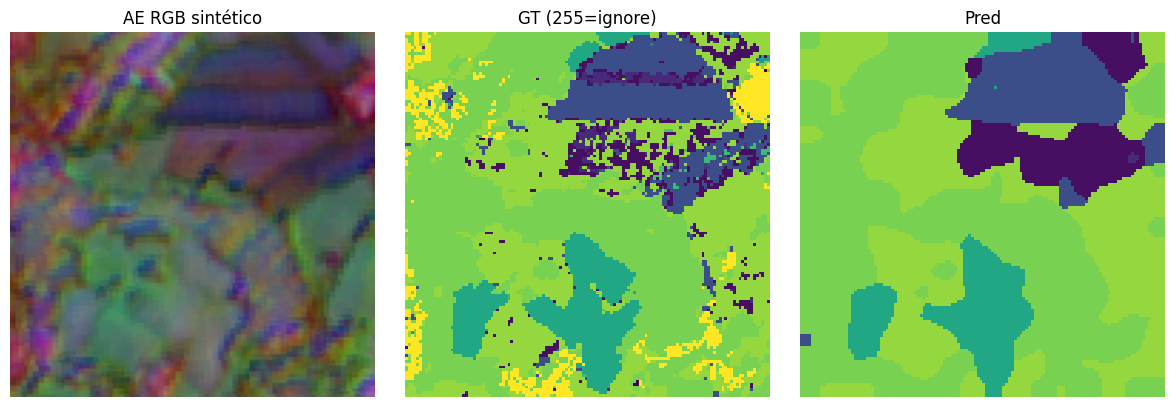

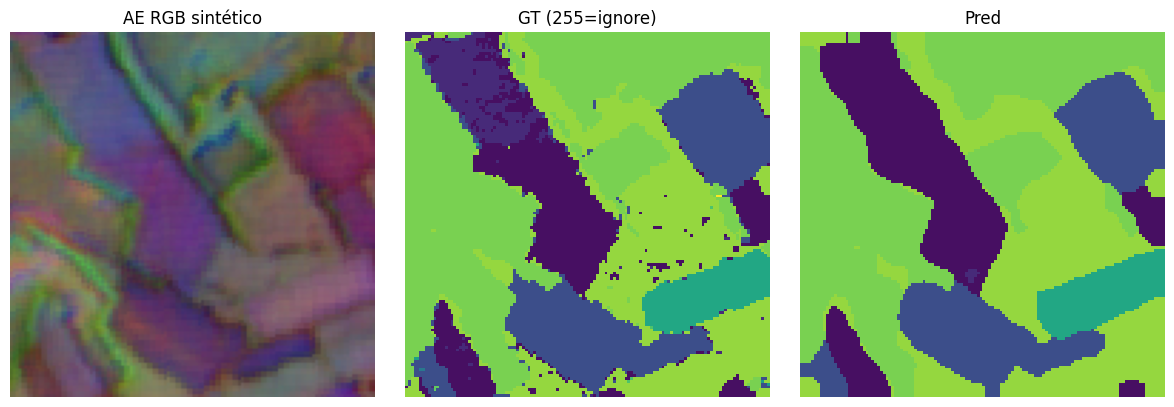

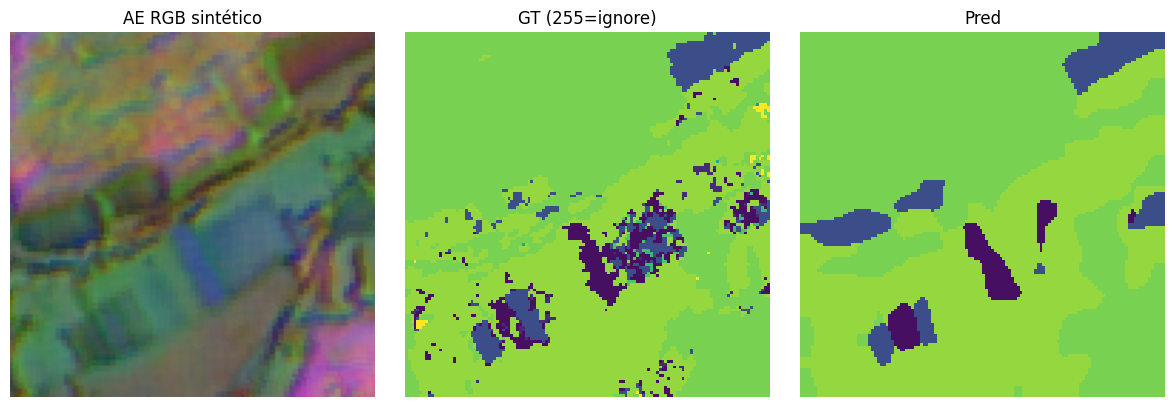

[TEST] loss=0.6982 | mIoU=0.255 | pixAcc=0.777
IoU por clase:
  [00] Artificial                                    IoU=0.024
  [01] Trigo común                                   IoU=0.596
  [02] Trigo duro                                    IoU=0.229
  [03] Barley                                        IoU=0.205
  [04] Centeno                                       IoU=0.000
  [05] Avena                                         IoU=0.000
  [06] Maíz                                          IoU=0.685
  [07] Arroz                                         IoU=0.000
  [08] Triticale                                     IoU=0.000
  [09] Otros cereales                                IoU=nan
  [10] Papas                                         IoU=0.008
  [11] Remolacha azucarera                           IoU=0.478
  [12] Otras raíces                                  IoU=0.000
  [13] Otros cultivos industriales no permanentes    IoU=0.243
  [14] Girasol                                       IoU=0

In [10]:
# ============= BLOQUE 8 — Visualización y Test (reutiliza utilidades) =============
@torch.no_grad()
def visualize_batch(loader, n=2):
    model.eval()
    Xb, Yb, _ = next(iter(loader))
    Xb = Xb.to(device); Yb = Yb.to(device)
    out    = model(Xb)
    logits = get_logits(out)
    preds  = logits.argmax(1)
    Xb = Xb.cpu().numpy(); Yb = Yb.cpu().numpy(); preds = preds.cpu().numpy()
    for i in range(min(n, Xb.shape[0])):
        x = np.transpose(Xb[i], (1,2,0))
        rgb = to_rgb(x)
        y  = Yb[i]; p = preds[i]
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(rgb); plt.title('AE RGB sintético'); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(y, vmin=0, vmax=NUM_CLASSES, interpolation='nearest'); plt.title('GT (255=ignore)'); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(p, vmin=0, vmax=NUM_CLASSES, interpolation='nearest'); plt.title('Pred'); plt.axis('off')
        plt.tight_layout(); plt.show()

visualize_batch(dlv, n=10)

# Métricas en TEST
@torch.no_grad()
def eval_test(loader):
    model.eval()
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)
    losses = []
    for X,Y,_ in loader:
        X = X.to(device); Y = Y.to(device)
        out    = model(X)
        logits = get_logits(out)
        losses.append(float(ce_loss(logits, Y).detach().cpu()))
        cm_total += compute_confmat(logits.argmax(1), Y)
    iou, miou = iou_from_confmat(cm_total)
    acc = pixel_accuracy(cm_total)
    return np.mean(losses), float(miou.item()), float(acc), iou.detach().cpu().numpy()

test_loss, test_miou, test_acc, iou_per_class = eval_test(dls)
print(f"[TEST] loss={test_loss:.4f} | mIoU={test_miou:.3f} | pixAcc={test_acc:.3f}")
print("IoU por clase:")
for idx, iou_c in enumerate(iou_per_class):
    name = NAMES[idx]
    print(f"  [{idx:02d}] {name:<45} IoU={float(iou_c):.3f}")
